In [15]:
import pandas as pd
import numpy as np

In [16]:
clean_data = pd.read_parquet("../cleaned_data/clean_yellow_tripdata_2026-01.parquet")

In [17]:
df = clean_data.copy()

In [18]:
df['vendor_id'].sample(3)

73540      2
639800     2
3679892    2
Name: vendor_id, dtype: int32

In [19]:
df['vendor_id'].isna().sum()

np.int64(0)

In [20]:
df['vendor_id'].value_counts()

vendor_id
2    2965742
1     710425
7      44705
6       4017
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

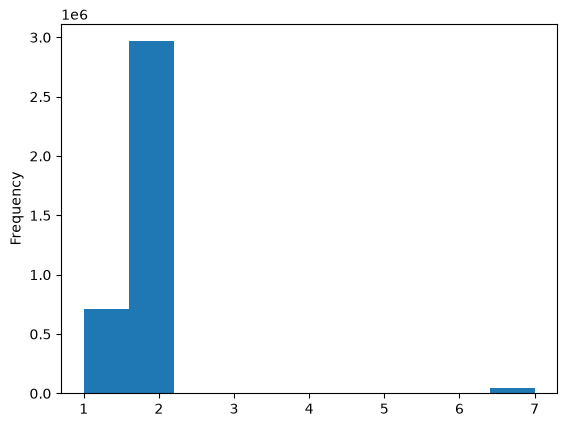

In [21]:
df['vendor_id'].plot(kind='hist')

In [22]:
df['vendor_name'] = df['vendor_id'].map({
    1 : 'Creative Mobile Technologies, LLC',
    2 : 'Curb Mobility, LLC',
    6 : 'Myle Technologies Inc',
    7 : 'Helix'
})

In [23]:
df['vendor_name'] = df['vendor_name'].fillna('Unkown Provider')

In [24]:
df[['vendor_id', 'vendor_name']].sample(5)

,vendor_id,vendor_name
3156918,1,"Creative Mobile Technologies, LLC"
2883537,2,"Curb Mobility, LLC"
2134923,2,"Curb Mobility, LLC"
3694221,2,"Curb Mobility, LLC"
2791301,2,"Curb Mobility, LLC"


In [25]:
df['vendor_id'] = df['vendor_id'].astype('int8')

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 21 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   vendor_id                     int8          
 1   pickup_datetime               datetime64[us]
 2   dropoff_datetime              datetime64[us]
 3   passenger_count               float64       
 4   trip_distance                 float64       
 5   fare_type_id                  float64       
 6   store_and_fwd_flag            str           
 7   pickup_location_id            int32         
 8   dropoff_location_id           int32         
 9   payment_type                  int64         
 10  fare_amount                   float64       
 11  extra_amount                  float64       
 12  mta_tax_amount                float64       
 13  tip_amount                    float64       
 14  tolls_amount                  float64       
 15  improvement_surcharge_amount  float64      

In [27]:
df['vendor_id'].value_counts()

vendor_id
2    2965742
1     710425
7      44705
6       4017
Name: count, dtype: int64

In [28]:
df.shape

(3724889, 21)

# save back to clean data file

In [29]:
df.to_parquet('../cleaned_data/clean_yellow_tripdata_2026-01.parquet', index=False)

In [31]:
def clean_vendor_id(df):

    df['vendor_name'] = df['vendor_id'].map({
        1 : 'Creative Mobile Technologies, LLC',
        2 : 'Curb Mobility, LLC',
        6 : 'Myle Technologies Inc',
        7 : 'Helix'
    })

    df['vendor_name'] = df['vendor_name'].fillna('Unkown Provider')